In [3]:
# IMPORTS AND SETTINGS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import logit
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
# Load the dataset 
df = pd.read_csv(r"C:\Users\user\Desktop\Data Folder\Virtual Patient Models_Dataset.csv")

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

# Convert dates to datetime
df['clinical_visit'] = pd.to_datetime(df['clinical_visit'], errors='coerce')
df['q_date'] = pd.to_datetime(df['q_date'], errors='coerce')

falls_col = 'falls_one_year'          
fractures_col = 'fractures_three_years'  

# Quick check for outcome columns
if falls_col not in df.columns or fractures_col not in df.columns:
    print(f" WARNING: '{falls_col}' or '{fractures_col}' not found. Please update column names in the next cell.")
else:
    print(f" Outcome columns '{falls_col}' and '{fractures_col}' detected.")

# Creating binary outcomes for logistic regression 
df['falls_binary'] = (df[falls_col] > 0).astype(int) if falls_col in df.columns else None
df['fractures_binary'] = (df[fractures_col] > 0).astype(int) if fractures_col in df.columns else None

print("\nOutcome distribution (binary):")
if 'falls_binary' in df.columns:
    print(df['falls_binary'].value_counts(normalize=True))
if 'fractures_binary' in df.columns:
    print(df['fractures_binary'].value_counts(normalize=True))

Dataset shape: (117, 59)

Column names:
['part_id', 'clinical_visit', 'fried', 'gender', 'q_date', 'age', 'comorbidities_most_important', 'hospitalization_one_year', 'hospitalization_three_years', 'ortho_hypotension', 'vision', 'audition', 'weight_loss', 'exhaustion_score', 'raise_chair_time', 'balance_single', 'gait_get_up', 'gait_speed_4m', 'gait_optional_binary', 'gait_speed_slower', 'grip_strength_abnormal', 'low_physical_activity', 'falls_one_year', 'fractures_three_years', 'bmi_score', 'bmi_body_fat', 'waist', 'lean_body_mass', 'screening_score', 'mna_total', 'cognitive_total_score', 'memory_complain', 'sleep', 'mmse_total_score', 'depression_total_score', 'anxiety_perception', 'living_alone', 'leisure_out', 'leisure_club', 'social_visits', 'social_calls', 'social_phone', 'social_skype', 'social_text', 'house_suitable_participant', 'house_suitable_professional', 'stairs_number', 'life_quality', 'health_rate', 'health_rate_comparison', 'pain_perception', 'activity_regular', 'smoki

,part_id,clinical_visit,fried,gender,q_date,age,comorbidities_most_important,hospitalization_one_year,hospitalization_three_years,ortho_hypotension,vision,audition,weight_loss,exhaustion_score,raise_chair_time,balance_single,gait_get_up,gait_speed_4m,gait_optional_binary,gait_speed_slower,grip_strength_abnormal,low_physical_activity,falls_one_year,fractures_three_years,bmi_score,bmi_body_fat,waist,lean_body_mass,screening_score,mna_total,cognitive_total_score,memory_complain,sleep,mmse_total_score,depression_total_score,anxiety_perception,living_alone,leisure_out,leisure_club,social_visits,social_calls,social_phone,social_skype,social_text,house_suitable_participant,house_suitable_professional,stairs_number,life_quality,health_rate,health_rate_comparison,pain_perception,activity_regular,smoking,alcohol_units,katz_index,iadl_grade,comorbidities_count,comorbidities_significant_count,medication_count
0,1084,1,Pre-frail,M,2016-10-05T22:52:28.000Z,78,Non of the above,0,0,No,Sees moderately,Hears moderately,No,1,14.0000,>5 sec,9.0500,8.8000,False,Yes,No,No,0,0,24.0955,22.8000,89.0000,50.6432,14,NaN,24.0000,No,No sleep problem,29,2,1.3000,No,7,Yes,1,7,180,0,0,Yes,Yes,17.0000,6.8000,4 - Good,3 - About the same,1.2000,> 5 h per week,Past smoker (stopped at least 6 months),1.5000,6.0000,29,6,2,5
1,1084,2,Pre-frail,M,2017-07-20T00:00:00.000Z,79,Non of the above,0,0,No,Sees moderately,Hears moderately,No,1,13.4600,>5 sec,10.3000,6.2000,False,Yes,No,No,0,0,24.2057,23.7000,89.0000,50.2817,14,NaN,27.0000,No,No sleep problem,30,2,1.7000,No,7,Yes,999,7,70,60,20,Yes,Yes,17.0000,7.2000,4 - Good,3 - About the same,1.0000,> 5 h per week,Past smoker (stopped at least 6 months),21.0000,6.0000,25,7,0,6
2,1084,3,Pre-frail,M,2017-12-01T00:00:00.000Z,79,Non of the above,0,0,No,Sees moderately,Hears moderately,No,1,13.4000,>5 sec,9.4000,7.2000,False,Yes,No,No,0,0,24.5761,23.2000,89.0000,50.7648,14,NaN,25.0000,No,No sleep problem,28,2,2.2000,No,7,Yes,1,4,120,30,5,NaN,NaN,NaN,6.5000,4 - Good,3 - About the same,1.3000,> 5 h per week,Past smoker (stopped at least 6 months),14.0000,6.0000,24,7,0,6
3,1084,4,Pre-frail,M,2018-09-24T00:00:00.000Z,80,Non of the above,0,0,No,Sees moderately,Hears moderately,No,1,14.1000,>5 sec,9.2000,6.4500,False,Yes,No,No,0,0,24.8364,23.2000,89.0000,51.3024,13,NaN,26.0000,No,Occasional sleep problem,26,3,4.8000,No,8,Yes,1,5,120,30,0,NaN,NaN,NaN,6.9000,4 - Good,3 - About the same,2.5000,> 5 h per week,Past smoker (stopped at least 6 months),18.0000,6.0000,26,8,0,7
4,1085,1,Non frail,F,2016-10-10T15:04:04.000Z,72,Non of the above,1,3,No,Sees well,Hears well,No,1,16.0000,>5 sec,9.8000,4.7000,False,No,No,No,0,0,23.4375,26.8000,96.0000,43.9200,11,22.5000,22.0000,Yes,Occasional sleep problem,25,2,10.0000,No,7,Yes,2,7,6,2,15,Yes,Yes,12.0000,7.3000,4 - Good,3 - About the same,2.5000,> 2 h and < 5 h per week,Past smoker (stopped at least 6 months),0.0000,6.0000,31,11,1,10


 Outcome columns 'falls_one_year' and 'fractures_three_years' detected.

Outcome distribution (binary):
falls_binary
0   0.8034
1   0.1966
Name: proportion, dtype: float64
fractures_binary
0   0.8718
1   0.1282
Name: proportion, dtype: float64


In [8]:
# DATA CLEANING AND PREPROCESSING
# Sort by patient and visit for longitudinal order
df = df.sort_values(['part_id', 'clinical_visit']).reset_index(drop=True)

# Key predictors and outcomes using exact column names from your CSV
predictors = ['gait_speed_4m', 'balance_single', 'raise_chair_time', 'gait_speed_slower',
              'age', 'gender', 'fried', 'ortho_hypotension', 'vision', 'audition',
              'hospitalization_one_year', 'hospitalization_three_years']

outcome_falls = 'falls_one_year'
outcome_fractures = 'fractures_three_years'

# Replace 999 with NaN in numeric columns
numeric_cols = ['gait_speed_4m', 'raise_chair_time', 'gait_speed_slower', 
                'hospitalization_one_year', 'hospitalization_three_years', 'age']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')   # Force numeric
        df[col] = df[col].replace(999, np.nan)

# Clean balance_single column (handles ">5 sec", "<5 sec", "test non realizable")
def clean_balance(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, str):
        val = val.strip().lower()
        if '>5 sec' in val:
            return 6.0
        elif '<5 sec' in val:
            return 3.0
        elif 'test non realizable' in val:
            return np.nan
    try:
        return float(val)
    except:
        return np.nan

df['balance_single'] = df['balance_single'].apply(clean_balance)

# Create binary outcomes
df['falls_binary'] = (df[outcome_falls] > 0).astype(int)
df['fractures_binary'] = (df[outcome_fractures] > 0).astype(int)

# Clinically meaningful binary variables
df['gait_slow'] = (df['gait_speed_4m'] < 0.8).astype(int)
df['balance_poor'] = (df['balance_single'] < 5).astype(int)

# Encode ortho_hypotension (Yes/No → 1/0)
df['ortho_hypotension'] = df['ortho_hypotension'].astype(str).str.strip()
df['ortho_hypotension_binary'] = (df['ortho_hypotension'].str.upper() == 'YES').astype(int)

# Encode gender
df['gender_male'] = (df['gender'].astype(str).str.upper() == 'M').astype(int)

# Log transform hospitalization
df['log_hospitalization_one_year'] = np.log1p(df['hospitalization_one_year'].fillna(0))

# Median imputation ONLY on numeric columns
numeric_predictors = ['gait_speed_4m', 'balance_single', 'raise_chair_time', 
                      'gait_speed_slower', 'age', 'hospitalization_one_year', 
                      'log_hospitalization_one_year']

for col in numeric_predictors:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("completed successfully.")
print(f"   • Total rows: {len(df)}")
print(f"   • Falls events: {df['falls_binary'].sum()} ({df['falls_binary'].mean():.1%})")
print(f"   • Fracture events: {df['fractures_binary'].sum()} ({df['fractures_binary'].mean():.1%})")
print("\nKey variables summary after cleaning:")
display(df[['gait_speed_4m', 'balance_single', 'age', 'ortho_hypotension_binary', 
            'gender_male', 'falls_binary', 'fractures_binary']].describe().round(3))

completed successfully.
   • Total rows: 117
   • Falls events: 23 (19.7%)
   • Fracture events: 15 (12.8%)

Key variables summary after cleaning:


,gait_speed_4m,balance_single,age,ortho_hypotension_binary,gender_male,falls_binary,fractures_binary
count,117.0000,117.0000,117.0000,117.0000,117.0000,117.0000,117.0000
mean,6.6200,4.9740,76.7260,0.0430,0.5730,0.1970,0.1280
std,3.5570,1.4290,3.4780,0.2030,0.4970,0.3990,0.3360
min,2.5400,3.0000,70.0000,0.0000,0.0000,0.0000,0.0000
25%,4.5700,3.0000,74.0000,0.0000,0.0000,0.0000,0.0000
50%,5.6000,6.0000,77.0000,0.0000,1.0000,0.0000,0.0000
75%,7.3000,6.0000,79.0000,0.0000,1.0000,0.0000,0.0000
max,22.8000,6.0000,85.0000,1.0000,1.0000,1.0000,1.0000


=== Descriptive Statistics by Outcome (Numeric Variables) ===

→ Mean values for falls:


,gait_speed_4m,balance_single,age
falls_binary,,,
0,6.6610,4.9790,76.5740
1,6.4520,4.9570,77.3480



Fried frailty distribution by falls:


fried,Frail,Non frail,Pre-frail
falls_binary,,,
0,17.0000,39.4000,43.6000
1,52.2000,17.4000,30.4000



→ Mean values for fractures:


,gait_speed_4m,balance_single,age
fractures_binary,,,
0,6.5920,4.9410,76.9410
1,6.8100,5.2000,75.2670



Fried frailty distribution by fractures:


fried,Frail,Non frail,Pre-frail
fractures_binary,,,
0,22.5000,38.2000,39.2000
1,33.3000,13.3000,53.3000


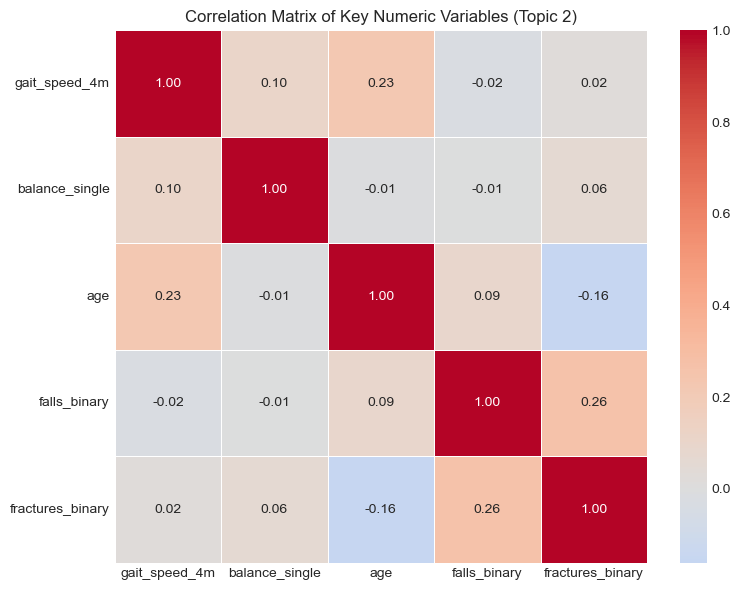

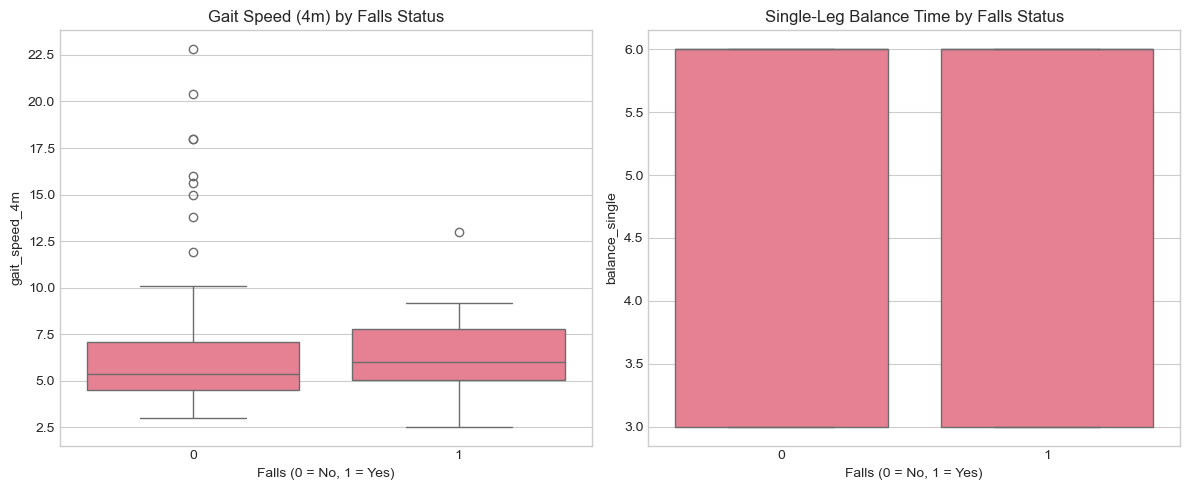

Figures saved successfully.


In [10]:
# EXPLORATORY DATA ANALYSIS (EDA) 
# Descriptive statistics by outcome - ONLY numeric variables
desc_vars = ['gait_speed_4m', 'balance_single', 'age', 'fried']   # fried will be handled separately

print("=== Descriptive Statistics by Outcome (Numeric Variables) ===")
for outcome in ['falls_binary', 'fractures_binary']:
    print(f"\n→ Mean values for {outcome.replace('_binary', '')}:")
    numeric_desc = ['gait_speed_4m', 'balance_single', 'age']
    display(df.groupby(outcome)[numeric_desc].mean().round(3))
    
    # Separate table for Fried frailty category (counts and percentages)
    print(f"\nFried frailty distribution by {outcome.replace('_binary', '')}:")
    display(pd.crosstab(df[outcome], df['fried'], normalize='index').round(3) * 100)

# Correlation heatmap - only numeric columns
corr_vars = ['gait_speed_4m', 'balance_single', 'age', 'falls_binary', 'fractures_binary']
corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Key Numeric Variables (Topic 2)')
plt.tight_layout()
plt.savefig('thesis_figure_1_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Boxplots: Gait speed and balance by fall status
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='falls_binary', y='gait_speed_4m', data=df, ax=axes[0])
axes[0].set_title('Gait Speed (4m) by Falls Status')
axes[0].set_xlabel('Falls (0 = No, 1 = Yes)')

sns.boxplot(x='falls_binary', y='balance_single', data=df, ax=axes[1])
axes[1].set_title('Single-Leg Balance Time by Falls Status')
axes[1].set_xlabel('Falls (0 = No, 1 = Yes)')

plt.tight_layout()
plt.savefig('thesis_figure_2_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figures saved successfully.")

In [12]:
# UNIVARIATE ANALYSIS

print("UNIVARIATE ASSOCIATIONS (t-tests) WITH FALLS")
for var in ['gait_speed_4m', 'balance_single', 'age']:
    group0 = df[df['falls_binary'] == 0][var]
    group1 = df[df['falls_binary'] == 1][var]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    print(f"{var:20} → t = {t_stat:.3f}, p = {p_val:.4f}")

print("\nFried Frailty Distribution by Falls:")
display(pd.crosstab(df['falls_binary'], df['fried'], normalize='index').round(3) * 100)

print("\n UNIVARIATE ASSOCIATIONS (t-tests) WITH FRACTURES ")
for var in ['gait_speed_4m', 'balance_single', 'age']:
    group0 = df[df['fractures_binary'] == 0][var]
    group1 = df[df['fractures_binary'] == 1][var]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False, nan_policy='omit')
    print(f"{var:20} → t = {t_stat:.3f}, p = {p_val:.4f}")

print("\nFried Frailty Distribution by Fractures:")
display(pd.crosstab(df['fractures_binary'], df['fried'], normalize='index').round(3) * 100)

print("completed successfully.")

UNIVARIATE ASSOCIATIONS (t-tests) WITH FALLS
gait_speed_4m        → t = 0.342, p = 0.7333
balance_single       → t = 0.066, p = 0.9481
age                  → t = -0.919, p = 0.3652

Fried Frailty Distribution by Falls:


fried,Frail,Non frail,Pre-frail
falls_binary,,,
0,17.0000,39.4000,43.6000
1,52.2000,17.4000,30.4000



 UNIVARIATE ASSOCIATIONS (t-tests) WITH FRACTURES 
gait_speed_4m        → t = -0.287, p = 0.7767
balance_single       → t = -0.677, p = 0.5065
age                  → t = 2.190, p = 0.0393

Fried Frailty Distribution by Fractures:


fried,Frail,Non frail,Pre-frail
fractures_binary,,,
0,22.5000,38.2000,39.2000
1,33.3000,13.3000,53.3000


completed successfully.


In [15]:
#  MULTIVARIABLE LOGISTIC REGRESSION 
# Ensuring outcomes are properly typed as integer
df['falls_binary'] = df['falls_binary'].astype(int)
df['fractures_binary'] = df['fractures_binary'].astype(int)

# Base predictors (all numeric/binary - safe for modeling)
base_predictors = ['gait_speed_4m', 'balance_single', 'age', 'gender_male', 
                   'ortho_hypotension_binary', 'log_hospitalization_one_year']

formula = 'falls_binary ~ ' + ' + '.join(base_predictors)

# Model 1: Falls
model_falls = logit(formula, data=df).fit(disp=0)
print("=== Multivariable Logistic Regression: Outcome = Falls (One Year) ===")
print(model_falls.summary2().tables[1].round(4))

# Odds Ratios with 95% CI
params = model_falls.params
conf = model_falls.conf_int()
or_falls = pd.DataFrame({
    'OR': np.exp(params),
    'Lower 95% CI': np.exp(conf[0]),
    'Upper 95% CI': np.exp(conf[1])
}).round(3)
print("\nOdds Ratios (95% CI) - Falls:")
print(or_falls)

# Model 2: Fractures
formula_frac = 'fractures_binary ~ ' + ' + '.join(base_predictors)
model_frac = logit(formula_frac, data=df).fit(disp=0)
print("\n=== Multivariable Logistic Regression: Outcome = Fractures (Three Years) ===")
print(model_frac.summary2().tables[1].round(4))

or_frac = pd.DataFrame({
    'OR': np.exp(model_frac.params),
    'Lower 95% CI': np.exp(model_frac.conf_int()[0]),
    'Upper 95% CI': np.exp(model_frac.conf_int()[1])
}).round(3)
print("\nOdds Ratios (95% CI) - Fractures:")
print(or_frac)

print("\n Both models fitted using formula interface.")

=== Multivariable Logistic Regression: Outcome = Falls (One Year) ===
                               Coef.  Std.Err.       z  P>|z|   [0.025  0.975]
Intercept                    -7.9587    5.6961 -1.3972 0.1623 -19.1229  3.2055
gait_speed_4m                 0.0128    0.0802  0.1593 0.8734  -0.1445  0.1701
balance_single               -0.0019    0.1865 -0.0103 0.9918  -0.3675  0.3636
age                           0.0785    0.0734  1.0704 0.2844  -0.0653  0.2224
gender_male                  -0.1407    0.5714 -0.2462 0.8055  -1.2607  0.9793
ortho_hypotension_binary      0.0905    1.2485  0.0725 0.9422  -2.3566  2.5375
log_hospitalization_one_year  2.4387    0.7048  3.4599 0.0005   1.0572  3.8201

Odds Ratios (95% CI) - Falls:
                                  OR  Lower 95% CI  Upper 95% CI
Intercept                     0.0000        0.0000       24.6680
gait_speed_4m                 1.0130        0.8650        1.1850
balance_single                0.9980        0.6920        1.4390
age    

=== Model Performance on Held-Out Test Set (Falls) ===
AUC-ROC: 0.483

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87        29
           1       0.33      0.14      0.20         7

    accuracy                           0.78        36
   macro avg       0.58      0.54      0.54        36
weighted avg       0.72      0.78      0.74        36



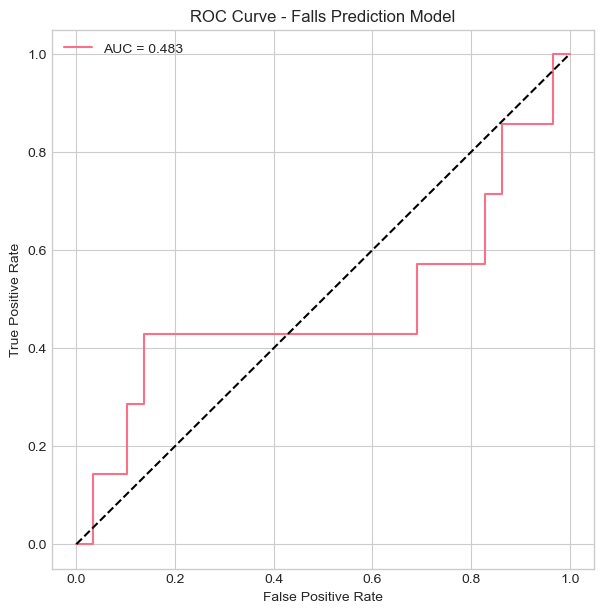

Validation metrics calculated.


In [18]:
# MODEL VALIDATION AND PERFORMANCE 
# Internal validation for Falls model (70/30 stratified split)
X = df[base_predictors].copy()          # Use same predictors 
y = df['falls_binary'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Add constant for statsmodels and fit on training data
X_train_const = sm.add_constant(X_train)
model_train = sm.Logit(y_train, X_train_const).fit(disp=0)

# Predict on test set
X_test_const = sm.add_constant(X_test)
y_pred_prob = model_train.predict(X_test_const)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("=== Model Performance on Held-Out Test Set (Falls) ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_prob):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Falls Prediction Model')
plt.legend()
plt.grid(True)
plt.savefig('thesis_figure_3_roc_falls.png', dpi=300, bbox_inches='tight')
plt.show()

print("Validation metrics calculated.")

In [20]:
print("Sensitivity Analysis: Females-only Model (Falls) ")

# Filter females
df_female = df[df['gender'].astype(str).str.upper() == 'F'].copy()

if len(df_female) > 10 and df_female['falls_binary'].sum() > 1:   # Avoid fitting on too few events
    # Use formula interface for reliability
    female_formula = 'falls_binary ~ gait_speed_4m + balance_single + age + ortho_hypotension_binary + log_hospitalization_one_year'
    
    model_f = logit(female_formula, data=df_female).fit(disp=0)
    print(model_f.summary2().tables[1].round(4))
    
    # Odds Ratios for females
    or_female = pd.DataFrame({
        'OR': np.exp(model_f.params),
        'Lower 95% CI': np.exp(model_f.conf_int()[0]),
        'Upper 95% CI': np.exp(model_f.conf_int()[1])
    }).round(3)
    print("\nOdds Ratios (95% CI) - Females only:")
    print(or_female)
else:
    print("Not enough female participants or falls events for stable model fitting.")

Sensitivity Analysis: Females-only Model (Falls) 
                                Coef.   Std.Err.       z  P>|z|       [0.025  \
Intercept                    -16.3535     9.0085 -1.8153 0.0695     -34.0098   
gait_speed_4m                 -0.1031     0.1134 -0.9097 0.3630      -0.3254   
balance_single                 0.4353     0.3289  1.3235 0.1857      -0.2093   
age                            0.1724     0.1083  1.5924 0.1113      -0.0398   
ortho_hypotension_binary     -20.9129 58586.0449 -0.0004 0.9997 -114847.4509   
log_hospitalization_one_year   2.1934     0.9785  2.2416 0.0250       0.2755   

                                  0.975]  
Intercept                         1.3028  
gait_speed_4m                     0.1191  
balance_single                    1.0800  
age                               0.3846  
ortho_hypotension_binary     114805.6252  
log_hospitalization_one_year      4.1114  

Odds Ratios (95% CI) - Females only:
                                 OR  Lower 95% CI 

In [21]:
# LONGITUDINAL DATA PREPARATION & DESCRIPTIVE ANALYSIS
print("Longitudinal Trajectories of Fried Frailty and Recurrent Hospitalization")
df['part_id'] = df['part_id'].astype(str)
df['clinical_visit'] = pd.to_datetime(df['clinical_visit'], errors='coerce')
df['fried'] = df['fried'].astype(str).str.strip()
df['hospitalization_one_year'] = pd.to_numeric(df['hospitalization_one_year'], errors='coerce').fillna(0).astype(int)
df['hospitalization_three_years'] = pd.to_numeric(df['hospitalization_three_years'], errors='coerce').fillna(0).astype(int)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Create a simple time variable (visit number per patient)
df['visit_number'] = df.groupby('part_id').cumcount() + 1

# Create binary recurrent hospitalization outcome (any hospitalization in the period)
df['hosp_one_year_binary'] = (df['hospitalization_one_year'] > 0).astype(int)

print(f"Dataset ready for longitudinal analysis.")
print(f"• Unique patients: {df['part_id'].nunique()}")
print(f"• Total visits: {len(df)}")
print(f"• Mean visits per patient: {len(df)/df['part_id'].nunique():.2f}")

# Descriptive statistics by Fried category
print("\nFried Frailty Distribution:")
display(df['fried'].value_counts(normalize=True).round(3) * 100)

print("\nMean Hospitalizations by Fried Category:")
display(df.groupby('fried')['hospitalization_one_year'].mean().round(3))

# Transition matrix (how frailty changes across visits)
print("\nFried Frailty Transitions (Visit n to Visit n+1):")
fried_pivot = df.pivot_table(index='part_id', columns='visit_number', values='fried', aggfunc='first')
print(fried_pivot.head(10))

Longitudinal Trajectories of Fried Frailty and Recurrent Hospitalization
Dataset ready for longitudinal analysis.
• Unique patients: 30
• Total visits: 117
• Mean visits per patient: 3.90

Fried Frailty Distribution:


fried
Pre-frail   41.0000
Non frail   35.0000
Frail       23.9000
Name: proportion, dtype: float64


Mean Hospitalizations by Fried Category:


fried
Frail       0.4290
Non frail   0.2440
Pre-frail   0.1250
Name: hospitalization_one_year, dtype: float64


Fried Frailty Transitions (Visit n to Visit n+1):
visit_number          1          2          3          4
part_id                                                 
1084          Pre-frail  Pre-frail  Pre-frail  Pre-frail
1085          Non frail  Non frail  Pre-frail  Non frail
1086          Non frail  Non frail  Non frail  Non frail
1088              Frail      Frail      Frail      Frail
1089          Pre-frail  Pre-frail  Pre-frail  Pre-frail
1090          Pre-frail  Pre-frail  Pre-frail  Pre-frail
1091          Non frail  Non frail  Non frail  Non frail
1092          Non frail  Non frail  Non frail  Non frail
1093          Non frail  Non frail  Non frail  Non frail
1094          Pre-frail  Pre-frail  Non frail  Pre-frail


In [22]:
# MIXED-EFFECTS MODELS (Longitudinal Trajectories)
import statsmodels.formula.api as smf

# Mixed-effects logistic regression: Probability of hospitalization ~ Fried + Time + Age
# Random intercept for each patient 

formula_mixed = 'hosp_one_year_binary ~ C(fried, Treatment("Non frail")) + age + visit_number'

model_mixed = smf.mixedlm(formula_mixed, 
                          data=df, 
                          groups=df['part_id']).fit()

print(" Mixed-Effects Logistic Regression: Hospitalization Risk")
print(model_mixed.summary())

# Odds ratios (approximate for mixed models)
print("\nApproximate Odds Ratios:")
or_mixed = np.exp(model_mixed.params)
print(or_mixed.round(3))

 Mixed-Effects Logistic Regression: Hospitalization Risk
                         Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        hosp_one_year_binary
No. Observations:         117            Method:                    REML                
No. Groups:               30             Scale:                     0.0408              
Min. group size:          3              Log-Likelihood:            -26.9205            
Max. group size:          4              Converged:                 Yes                 
Mean group size:          3.9                                                           
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                     -0.067    1.496 -0.045 0.964 -3.0

Mean Fried Score Over Visits


visit_number
1   1.0000
2   0.9330
3   0.7670
4   0.8520
Name: fried_score, dtype: float64

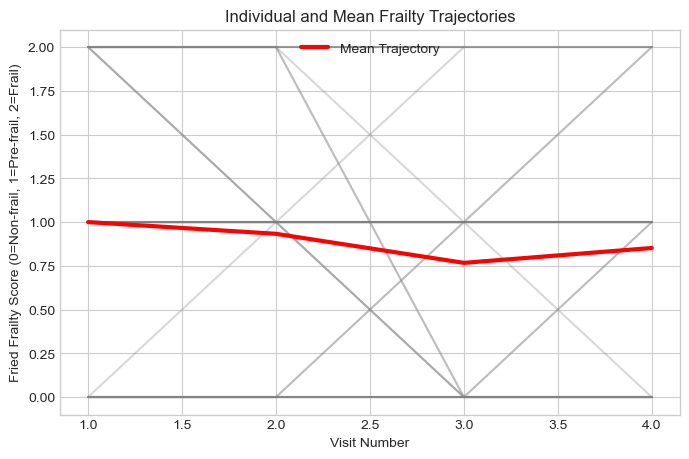

In [23]:
# GROUP-BASED TRAJECTORY ANALYSIS 
# Create frailty score as ordinal for trajectory modeling
fried_map = {'Non frail': 0, 'Pre-frail': 1, 'Frail': 2}
df['fried_score'] = df['fried'].map(fried_map)

print("Mean Fried Score Over Visits")
trajectory = df.groupby('visit_number')['fried_score'].mean().round(3)
display(trajectory)

# Plot trajectories
plt.figure(figsize=(8, 5))
for pid in df['part_id'].unique()[:30]:  # Plot first 30 patients for clarity
    patient_data = df[df['part_id'] == pid]
    plt.plot(patient_data['visit_number'], patient_data['fried_score'], alpha=0.3, color='gray')

plt.plot(trajectory.index, trajectory.values, color='red', linewidth=3, label='Mean Trajectory')
plt.xlabel('Visit Number')
plt.ylabel('Fried Frailty Score (0=Non-frail, 1=Pre-frail, 2=Frail)')
plt.title('Individual and Mean Frailty Trajectories')
plt.legend()
plt.grid(True)
plt.savefig('thesis_figure_4_frailty_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
# PREDICTORS OF HOSPITALIZATION (Poisson for Count Data)
# Poisson regression for count of hospitalizations 
formula_poisson = 'hospitalization_one_year ~ C(fried, Treatment("Non frail")) + age + gender_male + ortho_hypotension_binary'

model_poisson = smf.poisson(formula_poisson, data=df).fit(disp=0)

print("Poisson Regression: Predictors of Hospitalization Count")
print(model_poisson.summary2().tables[1].round(4))

# Incidence Rate Ratios (IRR)
irr = pd.DataFrame({
    'IRR': np.exp(model_poisson.params),
    'Lower 95% CI': np.exp(model_poisson.conf_int()[0]),
    'Upper 95% CI': np.exp(model_poisson.conf_int()[1])
}).round(3)
print("\nIncidence Rate Ratios (95% CI):")
print(irr)

Poisson Regression: Predictors of Hospitalization Count
                                                Coef.  Std.Err.       z  \
Intercept                                      3.3052    4.4376  0.7448   
C(fried, Treatment("Non frail"))[T.Frail]      0.7573    0.4885  1.5502   
C(fried, Treatment("Non frail"))[T.Pre-frail] -0.6188    0.5261 -1.1761   
age                                           -0.0635    0.0593 -1.0709   
gender_male                                    0.1076    0.4086  0.2634   
ortho_hypotension_binary                       0.1837    1.0342  0.1777   

                                               P>|z|  [0.025  0.975]  
Intercept                                     0.4564 -5.3924 12.0028  
C(fried, Treatment("Non frail"))[T.Frail]     0.1211 -0.2001  1.7147  
C(fried, Treatment("Non frail"))[T.Pre-frail] 0.2396 -1.6499  0.4124  
age                                           0.2842 -0.1798  0.0527  
gender_male                                   0.7923 -0.6932  0

In [25]:
# COMPARISON OF FRAILTY INDICES
print("Comparison of Frailty Indices")
print("Evaluating how different frailty-related measures predict hospitalization risk\n")

# Create a binary frailty indicator for simplicity
df['frail_binary'] = (df['fried'].isin(['Frail', 'Pre-frail'])).astype(int)

# List of frailty-related predictors to compare
frailty_indices = {
    'Fried Category (3-level)': 'C(fried, Treatment("Non frail"))',
    'Fried Binary (Frail/Pre-frail vs Non-frail)': 'frail_binary',
    'Fried Score (Ordinal)': 'fried_score',
    'Gait Speed (continuous)': 'gait_speed_4m',
    'Single-Leg Balance': 'balance_single',
    'Grip Strength Abnormal': 'grip_strength_abnormal',
    'Exhaustion Score': 'exhaustion_score',
    'Low Physical Activity': 'low_physical_activity'
}

results = []

for name, predictor in frailty_indices.items():
    try:
        if 'C(fried' in predictor:
            formula = f'hosp_one_year_binary ~ {predictor} + age + gender_male'
            model = logit(formula, data=df).fit(disp=0)
        else:
            formula = f'hosp_one_year_binary ~ {predictor} + age + gender_male'
            model = logit(formula, data=df).fit(disp=0)
        
        # Extract key statistics for the frailty predictor
        params = model.params
        pvalues = model.pvalues
        conf = model.conf_int()
        
        # Get the main frailty coefficient (first non-intercept)
        frailty_coef = params.iloc[1] if len(params) > 1 else np.nan
        frailty_p = pvalues.iloc[1] if len(pvalues) > 1 else np.nan
        or_val = np.exp(frailty_coef)
        lower = np.exp(conf.iloc[1, 0])
        upper = np.exp(conf.iloc[1, 1])
        
        results.append({
            'Frailty Index': name,
            'OR': round(or_val, 3),
            '95% CI Lower': round(lower, 3),
            '95% CI Upper': round(upper, 3),
            'p-value': round(frailty_p, 4),
            'AIC': round(model.aic, 1)
        })
        
    except Exception as e:
        results.append({
            'Frailty Index': name,
            'OR': 'Error',
            '95% CI Lower': 'Error',
            '95% CI Upper': 'Error',
            'p-value': 'Error',
            'AIC': 'Error'
        })

# Create comparison table
comparison_df = pd.DataFrame(results)
display(comparison_df.sort_values('AIC'))

print("\n Frailty indices comparison completed.")
print("Lower AIC indicates better model fit. Smaller p-value and OR farther from 1 indicate stronger predictor.")

Comparison of Frailty Indices
Evaluating how different frailty-related measures predict hospitalization risk



,Frailty Index,OR,95% CI Lower,95% CI Upper,p-value,AIC
3,Gait Speed (continuous),0.7570,0.5710,1.0040,0.0531,114.1000
7,Low Physical Activity,4.7670,1.2510,18.1550,0.0221,114.4000
1,Fried Binary (Frail/Pre-frail vs Non-frail),0.6620,0.2450,1.7870,0.4158,118.9000
5,Grip Strength Abnormal,1.4910,0.5570,3.9940,0.4269,119.0000
4,Single-Leg Balance,1.1120,0.7860,1.5740,0.5471,119.2000
0,Fried Category (3-level),1.1810,0.3240,4.2990,0.8010,119.2000
2,Fried Score (Ordinal),0.9910,0.5000,1.9610,0.9782,119.6000
6,Exhaustion Score,1.0970,0.3480,3.4560,0.8739,119.6000



 Frailty indices comparison completed.
Lower AIC indicates better model fit. Smaller p-value and OR farther from 1 indicate stronger predictor.
